## Bayesian Static Spin-Orbit Tomography (Type 1)

This code retrieves a surface map from reflection integrated light curve of an Earth analog based on a Bayesian modeling conditioned on hyperparameters and nonlinear parameters.

- Section 2 in Kawahara and Masuda 2020

See also
- Farr et al. 2018 
- Kawahara & Fujii 2010 (http://adsabs.harvard.edu/cgi-bin/bib_query?arXiv:1004.5152)
- Kawahara & Fujii 2011 (http://adsabs.harvard.edu/cgi-bin/bib_query?arXiv:1106.0136)
- Fujii & Kawahara 2012 (http://adsabs.harvard.edu/cgi-bin/bib_query?arXiv:1204.3504)

for more details.  You need Healpy, Scikit-learn, sot package https://github.com/HajimeKawahara/sot.
Add sot/sot/core in your PYTHONPATH.

The posterior of ${\boldsymbol{m}}$ for the linear inverse problem $\boldsymbol{d} = W \boldsymbol{m}$ with the data covariance $\Sigma_{{\boldsymbol{d}}}$ and the model covariance $\Sigma_{{\boldsymbol{m}}}$ is given by 

$p({\boldsymbol{m}}|{\boldsymbol{d}},{\boldsymbol{\theta}}, {{\boldsymbol{g}}}) = \mathcal{N}({\boldsymbol{m}}| {\boldsymbol{\mu}}_{{\boldsymbol{m}}|{\boldsymbol{d}},{\boldsymbol{\theta}}, {\boldsymbol{g}}},\Sigma_{{\boldsymbol{m}}|{\boldsymbol{d}},{\boldsymbol{\theta}}, {\boldsymbol{g}}}) $

${\boldsymbol{\mu}}_{{\boldsymbol{m}}|{\boldsymbol{d}},{\boldsymbol{\theta}},{\boldsymbol{g}}} = ( W^T \Pi_{{\boldsymbol{d}}} W + \Pi_{{\boldsymbol{m}}} )^{-1} W^T \Pi_{{\boldsymbol{d}}} {\boldsymbol{d}} = ( W^T \Pi_{{\boldsymbol{d}}} W + K_S^{-1} )^{-1} W^T \Pi_{\boldsymbol{d}} {\boldsymbol{d}} $

$\Sigma_{{\boldsymbol{m}}|{\boldsymbol{d}},{\boldsymbol{\theta}}, {\boldsymbol{g}}} = (W^T \Pi_{{\boldsymbol{d}}} W + \Pi_{{\boldsymbol{m}}})^{-1} = (W^T \Pi_{{\boldsymbol{d}}} W + K_S^{-1})^{-1} $

where

$\Pi_{{\boldsymbol{d}}} = \Sigma_{{\boldsymbol{d}}}^{-1}$

$\Pi_{{\boldsymbol{m}}} = \Sigma_{{\boldsymbol{m}}}^{-1}$

See Section 2 in Kawahara and Masuda 2020 for more details.

Here, we will consider three-types of the kernel $K_S$, L2, RBF, and Matern-3/2.

In [2]:
%load_ext autoreload
%reload_ext autoreload
%matplotlib inline

In [3]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from sot.core.weight import compute_weight 
np.random.seed(57)

In [4]:
# set geometry
inc = 45.0 / 180.0 * np.pi
Thetaeq = np.pi
# zeta=np.pi/3.0
zeta = 23.4 / 180.0 * np.pi
Pspin = 23.9344699 / 24.0  # Pspin: a sidereal day
wspin = 2 * np.pi / Pspin
Porb = 365.242190402
# Porb=40.0
worb = 2 * np.pi / Porb
Ni = 1024
obst = np.linspace(0.0, Porb, Ni)

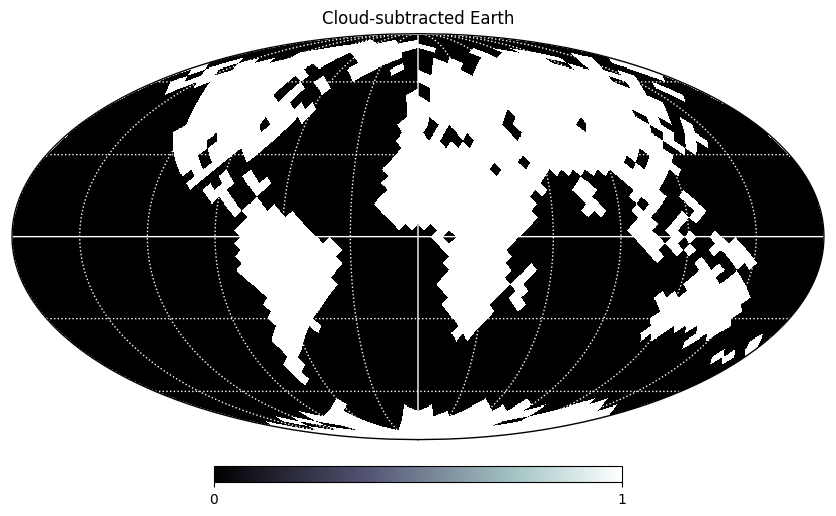

In [5]:
# test map
from sot.io.load_data import get_data_filepath
import matplotlib.pyplot as plt
nside = 16
npix = hp.nside2npix(nside)
file_path = get_data_filepath("mockalbedo16.fits")
mmap = hp.read_map(file_path)
mask = mmap > 0.0
mmap[mask] = 1.0
hp.mollview(
    mmap, title="Cloud-subtracted Earth", flip="geo", cmap=plt.cm.bone, min=0, max=1
)
# hp.mollview(Kvolall,title="Kvol",flip="geo",cmap=plt.cm.Spectral,min=-0.3,max=0.3)
hp.graticule(color="white")
M = len(mmap)
plt.savefig("mockalbedo16.png", dpi=300)

In [6]:
# generating light curve
from jaxinv.model.linear import type1
import jax.numpy as jnp
from sot.core.weight import compute_omega
Thetav = worb * obst
Phiv = np.mod(wspin * obst, 2 * np.pi)
omega = jnp.array(compute_omega(nside))
    
WI, WV = compute_weight(zeta, inc, Thetaeq, Thetav, Phiv, omega)
geometric_weight = jnp.array(WV[:, :] * WI[:, :])
mmap = jnp.array(mmap)
lc = type1(geometric_weight, mmap)
#lc = np.dot(W, mmap)

sigma = np.mean(lc) * 0.05
noise = np.random.normal(0.0, sigma, len(lc))
lc = lc + noise

/tmp/ipykernel_82060/1021067397.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper right", prop={"size": 11}, frameon=False)


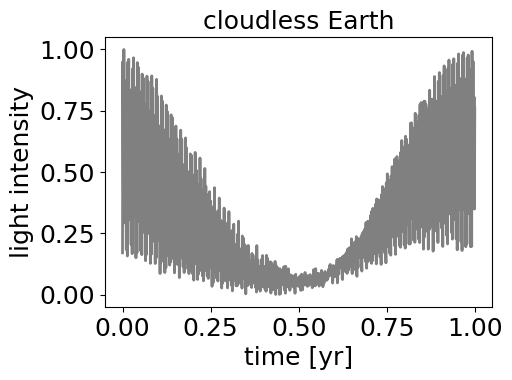

In [7]:
fig = plt.figure(figsize=(5, 3.5))
ax = fig.add_subplot(111)
ax.plot(obst / obst[-1], lc / np.max(lc), lw=2, color="gray")
plt.legend(loc="upper right", prop={"size": 11}, frameon=False)
plt.tick_params(labelsize=18)
plt.ylabel("light intensity", fontsize=18)
plt.xlabel("time [yr]", fontsize=18)
plt.title("cloudless Earth", fontsize=18)
plt.savefig("sotlc.png", bbox_inches="tight", pad_inches=0.0)
plt.show()

In [8]:
import matplotlib
fontsize=20
matplotlib.rcParams.update({'font.size':fontsize})

## RBF kernel

In [9]:
from sot.core import sepmat 
from jaxinv.bayes.gpkernel import rbf
from jaxinv.bayes.meanmap import meanmap_inverse_type1
import scipy

In [10]:
sep=sepmat.calc_sepmatrix(nside)
np.shape(np.shape(sep))[0]

2

In [11]:
import jax.numpy as jnp
gamma=0.32470597615966523
alpha=0.4172890000949949
Kernel_model_RBF=alpha*rbf(sep, gamma)
precision_matrix = np.eye(len(lc))/sigma**2
mu = meanmap_inverse_type1(geometric_weight, Kernel_model_RBF, precision_matrix, lc) #Ks@W.T@lc
cov = sigma**2 * Kernel_model_RBF

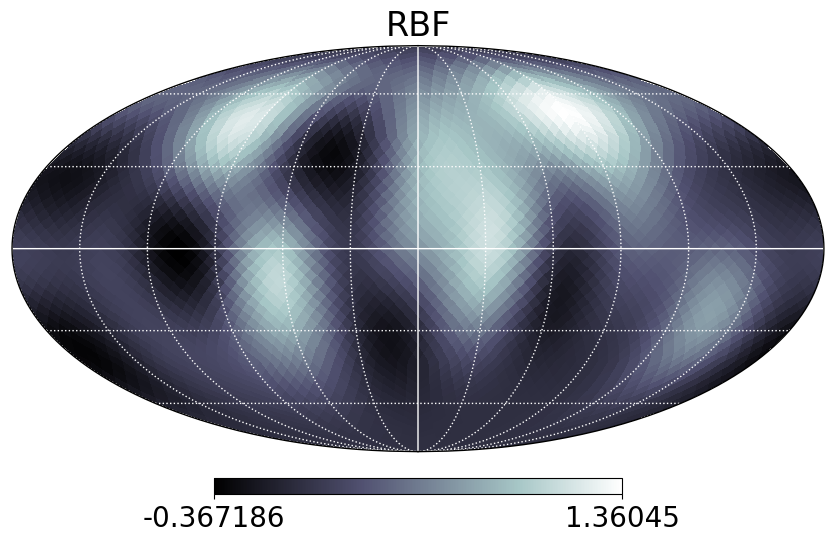

In [12]:
#best map
hp.mollview(mu, title="RBF",flip="geo",cmap=plt.cm.bone)#,min=0,max=1.0)
hp.graticule(color="white");
plt.savefig("sotrbfmap.pdf", bbox_inches="tight", pad_inches=0.0);

In [13]:
from numpyro.infer import MCMC, NUTS
import numpyro
import numpyro.distributions as dist
from jax import random
from jaxinv.bayes.weighted_kernel import grand_weighted_kernel_type1

/home/kawahara/anaconda3/envs/py310/lib/python3.10/site-packages/tqdm-4.66.5-py3.10.egg/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [27]:
Thetaeq = np.pi
zeta = 23.4 / 180.0 * np.pi


#from jax import jit
# jitrbf = jit(rbf)

def model(y):
    #geometric weight
    cos_zeta = numpyro.sample('u', dist.Uniform(-1.0, 1.0))
    zeta = jnp.arccos(cos_zeta)
    numpyro.deterministic('zeta', zeta)
    Thetaeq = numpyro.sample('Thetaeq', dist.Uniform(0.0, 2*jnp.pi))
    WI, WV = compute_weight(zeta, inc, Thetaeq, Thetav, Phiv, omega)
    geometric_weight = jnp.array(WV[:, :] * WI[:, :])
    
    #GP kernel
    #alpha = numpyro.sample('alpha', dist.Exponential(1.0))
    #gamma = numpyro.sample('gamma', dist.Exponential(1.0))
    gamma=0.32470597615966523
    alpha=0.4172890000949949
    Kernel_model_RBF=alpha*rbf(sep, gamma)

    #data noise
    sigma_d = numpyro.sample('sigma_d', dist.Exponential(1.0))

    kernel = sigma_d**2 * jnp.eye(len(y)) + grand_weighted_kernel_type1(geometric_weight, Kernel_model_RBF + 1.e-6*jnp.eye(Kernel_model_RBF.shape[0]))  
    mu = jnp.zeros_like(y)
    numpyro.sample('y', dist.MultivariateNormal(mu, kernel), obs=y)

In [28]:
rng_key = random.PRNGKey(0)
rng_key, rng_key_ = random.split(rng_key)
num_warmup, num_samples = 500, 1000
kernel = NUTS(model)
mcmc = MCMC(kernel, num_warmup=num_warmup, num_samples=num_samples)
mcmc.run(rng_key_, y=lc)
mcmc.print_summary()

sample: 100%|██████████| 1500/1500 [02:39<00:00,  9.41it/s, 7 steps of size 6.47e-01. acc. prob=0.92] 


                mean       std    median      5.0%     95.0%     n_eff     r_hat
   Thetaeq      3.19      0.03      3.19      3.15      3.24    687.85      1.00
   sigma_d      3.71      0.08      3.71      3.57      3.84    716.13      1.00
         u      0.92      0.01      0.92      0.91      0.93    762.51      1.00

Number of divergences: 0


In [30]:
np.mean(lc) * 0.05
jnp.arccos(0.92)*180/jnp.pi

Array(23.073915, dtype=float32, weak_type=True)

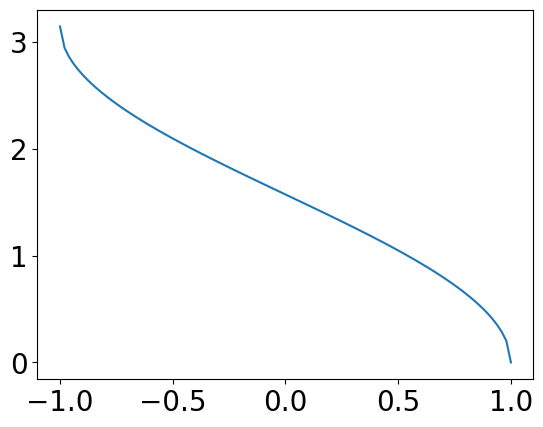

In [16]:
import matplotlib.pyplot as plt
x = jnp.linspace(-1.0, 1.0, 100)
plt.plot(x, jnp.arccos(x))